In [1]:
# Press Release mock image ROSALIA
# Alejandro Borlaff - NASA Ames Research Center
# a.s.borlaff@nasa.gov - August 5, 2026

# Plan: 
# Make a mock exposure object. 
# Run stray-light model. 

import rosalia as rs 
from astropy.time import Time
import os
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
os.chdir("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK")

In [8]:
# CAR171: OUT_pos_1_a_013 
# RA 88.23938768241827 DEC -48.53277317761877 PA 98.22514198825647 

# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 88.23938768241827  # Right ascension, in degrees. 
dec = -48.53277317761877  # Declination, in degrees.
PA = 98.22514198825647  # Position angle, in degrees.
date = Time('2026-12-01T00:00:00.0', format='isot', scale='utc')
bandpass = "F087"  # "F129" #  "F184" # # "F087" # Z087 J129 F184
exptime = 193 # Exposure time, in seconds.


observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": date.mjd, 
          "EXPTIME": exptime}

prefix = "PR_mock_" + bandpass
g_mag_max = 15

In [9]:
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 


> roman_wfi_exposure


Computing Zodiacal light...


100%|██████████| 18/18 [00:00<00:00, 938.35it/s]


Generating scaled mosaic...


18it [00:45,  2.50s/it]


DEMO WARNING: make_stray_plot is Assuming F129.
22.906927247552407
22.961422724828648


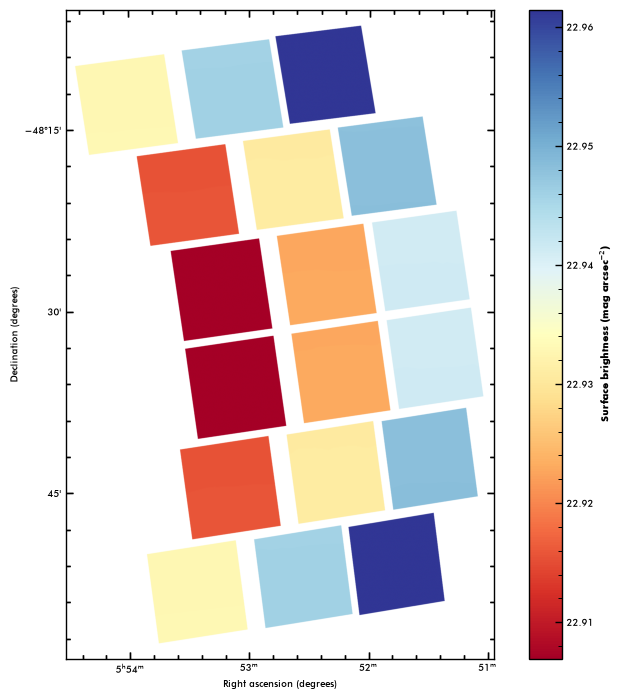

Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F087_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_zody.fits


{'zodi_list': [array([[0.324056  , 0.32405602, 0.32405604, ..., 0.32412831, 0.32412833,
          0.32412834],
         [0.324056  , 0.32405602, 0.32405603, ..., 0.32412831, 0.32412832,
          0.32412834],
         [0.32405599, 0.32405601, 0.32405603, ..., 0.32412831, 0.32412832,
          0.32412834],
         ...,
         [0.32405243, 0.32405244, 0.32405246, ..., 0.32412472, 0.32412474,
          0.32412476],
         [0.32405243, 0.32405244, 0.32405246, ..., 0.32412471, 0.32412473,
          0.32412475],
         [0.32405243, 0.32405244, 0.32405246, ..., 0.32412471, 0.32412473,
          0.32412475]], shape=(4088, 4088)),
  array([[0.31933083, 0.31933086, 0.31933088, ..., 0.31940197, 0.31940198,
          0.319402  ],
         [0.31933083, 0.31933085, 0.31933088, ..., 0.31940197, 0.31940198,
          0.31940199],
         [0.31933083, 0.31933085, 0.31933087, ..., 0.31940197, 0.31940198,
          0.31940199],
         ...,
         [0.31932561, 0.31932562, 0.31932564, ..., 0.31

In [10]:
custom_roman_exposure.zodiacal()

In [ ]:
straylight_background = custom_roman_exposure.straylight(g_mag_max=g_mag_max)

In [ ]:
# This notebook demonstrates how to use ROSALIA to analyze psf in a simple image. 
psf_background = custom_roman_exposure.psf_background(g_mag_max=g_mag_max, verbose=True)

In [15]:
# Get the zodiacal light background 
drz_name = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F087_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars_drz.fits" # psf_background.replace("_stars.fits", "_stars_drz.fits")

drz_fits = fits.open(drz_name)
import astropy.wcs as astropy_wcs
wcs =  astropy_wcs.WCS(header=drz_fits[0].header, fobj=drz_fits, naxis=2)
import numpy as np
for filter_pablo in ["F129"]: # ["F062", "F129", "F158"]:
    FILTER_IDENTITY = rs.telescopes.find_filter_in_svo(wavelength=filter_pablo,
                                                                        telescope=custom_roman_exposure.TELESCOP,
                                                                        instrument=custom_roman_exposure.INSTRUME, 
                                                                        detector=custom_roman_exposure.DETECTOR, verbose=False)
    zodiacal_background = rs.sky.get_zodiacal_background(wcs,
                                                         wavelength=FILTER_IDENTITY,
                                                         telescope=custom_roman_exposure.TELESCOP,
                                                         instrument=custom_roman_exposure.INSTRUME,
                                                         detector=custom_roman_exposure.DETECTOR,
                                                         expstart=custom_roman_exposure.EXPSTART,
                                                         step=1000, zody_mode="zodipy",
                                                         nbins_wavelength=5, obslocin=0,
                                                         grid_method="random",
                                                         output_units="e/s",
                                                         verbose=False)

    zodiacal_background_es = zodiacal_background.value
    zodiacal_background_es[np.isnan(drz_fits[0].data)] = np.nan
    zodiacal_background_es[drz_fits[0].data==0] = np.nan

    rs.utils.save_fits(np.float32(zodiacal_background_es), drz_name.replace("_stars_", "_zody_" + filter_pablo + "_"), drz_fits[0].header)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import Sersic2D

# Image grid
nx, ny = 400, 400
x = np.linspace(-200, 200, nx)
y = np.linspace(-200, 200, ny)
xx, yy = np.meshgrid(x, y)

# Sérsic parameters
amplitude = 1.0
r_eff = 1000.0
n = 1.0
x0, y0 = 0.0, 0.0

# Inclination as axis ratio q = cos(i)
inclination_deg = 85.0
q = np.cos(np.radians(inclination_deg))
ellip = 1 - q

# Position angle
pa_deg = 0.0
theta = np.radians(pa_deg)

# Base Sérsic model (no distortion)
sersic = Sersic2D(amplitude=amplitude,
                  r_eff=r_eff,
                  n=n,
                  x_0=x0,
                  y_0=y0,
                  ellip=ellip,
                  theta=theta)

# --- Apply S-shaped distortion ---
# S-shaped warp function
def s_warp(x, strength=0.2, scale=75):
    return strength * x * np.cos(x / scale)

# Warp coordinates
yy_warped = yy + s_warp(xx)  # add S-shape vertical displacement

# Evaluate Sérsic on warped coordinates
image = sersic(xx, yy_warped)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(image, origin='lower', cmap='inferno')
plt.colorbar(label="Intensity")
plt.title("Inclined 2D Sérsic with S-shaped Distortion")
plt.show()